# Participation-Weighted Fair Value in Limit Order Books

*Research notebook - NSE India, March 2026*

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install polars scipy scikit-learn -q

Mounted at /content/drive


In [ ]:
import numpy as np
import polars as pl
from scipy import stats
from sklearn.linear_model import Ridge
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import warnings, time

matplotlib.rcParams.update({
    'font.size': 11, 'axes.titlesize': 13, 'figure.dpi': 150,
    'axes.spines.top': False, 'axes.spines.right': False,
})
warnings.filterwarnings('ignore')

DATA_DIR = Path('/content/drive/MyDrive/lob_fairvalue/data')
OUT_DIR = Path('/content/drive/MyDrive/lob_fairvalue/outputs')
OUT_DIR.mkdir(exist_ok=True)

## 1. Data

183 equities and NIFTY/BANKNIFTY front-month futures. 5-level order book depth. 5 trading days (March 4-10, 2026).

*Collected using the kite-data collection algorithm deployed in AWS lightsail instance in Mumbai, IN*

In [ ]:
def load_equity(path):
    name = path.stem
    try:
        df = pl.read_parquet(path)
    except:
        return None
    if 'trade_date' not in df.columns or 'bid_price_1' not in df.columns:
        return None

    df = df.with_columns(
        pl.col('exchange_timestamp').dt.hour().alias('hour'),
        pl.col('exchange_timestamp').dt.minute().alias('minute'),
    )
    df = df.filter(
        ((pl.col('hour') == 9) & (pl.col('minute') >= 15))
        | ((pl.col('hour') >= 10) & (pl.col('hour') <= 14))
        | ((pl.col('hour') == 15) & (pl.col('minute') <= 30))
    )
    df = df.filter(
        (pl.col('bid_price_1') > 0) & (pl.col('ask_price_1') > 0)
        & (pl.col('ask_price_1') > pl.col('bid_price_1'))
    )

    n = len(df)
    if n < 5000:
        return None

    out = {'name': name, 'n': n, 'type': 'equity'}
    for side in ['bid', 'ask']:
        for field in ['price', 'qty', 'orders']:
            key = f'{side}_{field}'
            out[key] = np.column_stack([
                df[f'{side}_{field}_{i}'].to_numpy().astype(np.float64) for i in range(1, 6)
            ])

    out['mid'] = (out['bid_price'][:, 0] + out['ask_price'][:, 0]) / 2.0
    out['spread_bps'] = (out['ask_price'][:, 0] - out['bid_price'][:, 0]) / out['mid'] * 10000
    out['dates'] = np.array(df['trade_date'].to_list())
    out['days'] = sorted(set(out['dates'].tolist()))

    lp = df['last_price'].to_numpy().astype(np.float64)
    vol_raw = df['volume'].to_numpy().astype(np.float64)
    out['tick_vol'] = np.clip(np.diff(vol_raw, prepend=vol_raw[0]), 0, None)
    out['trade_sign'] = np.zeros(n)
    out['trade_sign'][lp >= out['ask_price'][:, 0]] = 1.0
    out['trade_sign'][lp <= out['bid_price'][:, 0]] = -1.0

    return out


def load_futures(path, symbol):
    df = pl.read_parquet(path)
    df = df.filter(pl.col('tradingsymbol') == symbol)
    df = df.with_columns(
        pl.col('received_timestamp').dt.hour().alias('hour'),
        pl.col('received_timestamp').dt.minute().alias('minute'),
        pl.col('received_timestamp').dt.date().cast(pl.Utf8).alias('trade_date'),
    )
    df = df.filter(
        ((pl.col('hour') == 9) & (pl.col('minute') >= 15))
        | ((pl.col('hour') >= 10) & (pl.col('hour') <= 14))
        | ((pl.col('hour') == 15) & (pl.col('minute') <= 30))
    )
    df = df.filter(
        (pl.col('bid_price_1') > 0) & (pl.col('ask_price_1') > 0)
        & (pl.col('ask_price_1') > pl.col('bid_price_1'))
    )
    df = df.sort('received_timestamp')

    n = len(df)
    if n < 5000:
        return None

    out = {'name': symbol, 'n': n, 'type': 'futures'}
    for side in ['bid', 'ask']:
        for field in ['price', 'qty', 'orders']:
            key = f'{side}_{field}'
            out[key] = np.column_stack([
                df[f'{side}_{field}_{i}'].to_numpy().astype(np.float64) for i in range(1, 6)
            ])

    out['mid'] = (out['bid_price'][:, 0] + out['ask_price'][:, 0]) / 2.0
    out['spread_bps'] = (out['ask_price'][:, 0] - out['bid_price'][:, 0]) / out['mid'] * 10000
    out['dates'] = np.array(df['trade_date'].to_list())
    out['days'] = sorted(set(out['dates'].tolist()))

    lp = df['last_price'].to_numpy().astype(np.float64)
    vol_raw = df['volume'].to_numpy().astype(np.float64)
    out['tick_vol'] = np.clip(np.diff(vol_raw, prepend=vol_raw[0]), 0, None)
    out['trade_sign'] = np.zeros(n)
    out['trade_sign'][lp >= out['ask_price'][:, 0]] = 1.0
    out['trade_sign'][lp <= out['bid_price'][:, 0]] = -1.0

    return out

In [ ]:
t0 = time.time()

equity_files = sorted([p for p in DATA_DIR.glob('*.parquet') if p.stem != 'index_futures'])
all_instruments = []

for i, path in enumerate(equity_files):
    r = load_equity(path)
    if r is not None:
        all_instruments.append(r)
    if (i + 1) % 40 == 0:
        print(f'  Equities: {i+1}/{len(equity_files)} ({time.time()-t0:.0f}s)')

n_equities = len(all_instruments)
print(f'Equities loaded: {n_equities} ({time.time()-t0:.0f}s)')

futures_path = DATA_DIR / 'index_futures.parquet'
if futures_path.exists():
    for sym in ['NIFTY26MARFUT', 'BANKNIFTY26MARFUT']:
        r = load_futures(futures_path, sym)
        if r is not None:
            all_instruments.append(r)
            print(f'Futures loaded: {sym} ({r["n"]:,} ticks)')

print(f'\nTotal instruments: {len(all_instruments)}')
print(f'  Equities: {n_equities}')
print(f'  Futures: {len(all_instruments) - n_equities}')

  Equities: 40/183 (33s)
  Equities: 80/183 (40s)
  Equities: 120/183 (44s)
  Equities: 160/183 (50s)
Equities loaded: 183 (52s)
Futures loaded: NIFTY26MARFUT (141,384 ticks)
Futures loaded: BANKNIFTY26MARFUT (131,873 ticks)

Total instruments: 185
  Equities: 183
  Futures: 2


## 2. Seven Fair Value Estimators

We define seven estimators and test which best predicts the future mid-price.

| Estimator | Weighting | Levels |
|---|---|---|
| Mid | none | — |
| Qty-L1 | quantity | L1 |
| Cnt-L1 | order count | L1 |
| Hyb-L1 | qty × count | L1 |
| Qty-L5 | quantity | L1-L5 |
| Cnt-L5 | order count | L1-L5 |
| Hyb-L5 | qty × count | L1-L5 |


In [ ]:
def compute_fair_values(s):
    n = s['n']
    bp, ap = s['bid_price'], s['ask_price']
    bq, aq = s['bid_qty'], s['ask_qty']
    bn, an = s['bid_orders'], s['ask_orders']
    mid = s['mid']

    fvs = {'mid': mid.copy()}

    fvs['qty_L1'] = (bp[:,0]*aq[:,0] + ap[:,0]*bq[:,0]) / (bq[:,0] + aq[:,0] + 1e-9)
    fvs['cnt_L1'] = (bp[:,0]*an[:,0] + ap[:,0]*bn[:,0]) / (bn[:,0] + an[:,0] + 1e-9)
    bw = bq[:,0]*bn[:,0]; aw = aq[:,0]*an[:,0]
    fvs['hyb_L1'] = (bp[:,0]*aw + ap[:,0]*bw) / (bw + aw + 1e-9)

    lam = 0.5
    w = np.array([np.exp(-lam*i) for i in range(5)])
    w /= w.sum()

    for tag, bw_fn, aw_fn in [
        ('qty_L5', lambda i: aq[:,i], lambda i: bq[:,i]),
        ('cnt_L5', lambda i: an[:,i], lambda i: bn[:,i]),
    ]:
        num = np.zeros(n); den = np.zeros(n)
        for i in range(5):
            num += w[i] * (bp[:,i]*bw_fn(i) + ap[:,i]*aw_fn(i))
            den += w[i] * (aw_fn(i) + bw_fn(i))
        fvs[tag] = num / (den + 1e-9)

    num_h = np.zeros(n); den_h = np.zeros(n)
    for i in range(5):
        bwi = bq[:,i]*bn[:,i]; awi = aq[:,i]*an[:,i]
        num_h += w[i] * (bp[:,i]*awi + ap[:,i]*bwi)
        den_h += w[i] * (bwi + awi)
    fvs['hyb_L5'] = num_h / (den_h + 1e-9)

    return fvs

## 3. Which FV Best Predicts the Future Mid?

For each instrument, on held-out test days:
- Compute each FV at tick t
- Compare to actual mid at tick t + H
- Measure **MSE ratio** (< 1 means FV beats mid as a forecast) and **rank IC** (does FV displacement predict return direction?)
- Non-overlapping evaluation windows



In [ ]:
HORIZONS = [10, 20, 50, 100]
WARMUP = 2000
FV_NAMES = ['mid', 'qty_L1', 'cnt_L1', 'hyb_L1', 'qty_L5', 'cnt_L5', 'hyb_L5']

results = {fn: {h: {'mse': [], 'ic': [], 'instruments': []} for h in HORIZONS} for fn in FV_NAMES}

for s in all_instruments:
    if len(s['days']) < 3:
        continue
    test_days = s['days'][-2:] if s['type'] == 'futures' else s['days'][3:]
    if not test_days:
        continue

    fvs = compute_fair_values(s)
    n, mid, dates = s['n'], s['mid'], s['dates']
    test_mask = np.isin(dates, test_days)
    test_mask[:WARMUP] = False

    for h in HORIZONS:
        future_mid = np.full(n, np.nan)
        future_mid[:n-h] = mid[h:]
        valid = test_mask & np.isfinite(future_mid)
        indices = np.where(valid)[0][::h]
        if len(indices) < 50:
            continue

        fm = future_mid[indices]
        m = mid[indices]
        mse_base = np.mean((fm - m)**2)
        if mse_base < 1e-15:
            continue

        for fn in FV_NAMES:
            fv = fvs[fn][indices]
            mse_fv = np.mean((fm - fv)**2)
            mse_ratio = mse_fv / mse_base

            disp = fv - m
            fwd = fm - m
            mask_ic = np.abs(disp) > 1e-9
            if mask_ic.sum() > 50:
                ic = stats.spearmanr(disp[mask_ic], fwd[mask_ic]).statistic
            else:
                ic = np.nan

            results[fn][h]['mse'].append(mse_ratio)
            results[fn][h]['ic'].append(ic)
            results[fn][h]['instruments'].append(s['name'])

n_tested = len(set(results['qty_L1'][50]['instruments']))
print(f'Instruments tested: {n_tested}')

Instruments tested: 185


In [ ]:
print(f'\n{"Estimator":>10s}', end='')
for h in HORIZONS:
    print(f'     H={h:<4d}          ', end='')
print()
print(f'{"":>10s}', end='')
for h in HORIZONS:
    print(f'   {"MSE":>7s} {"IC":>7s}   ', end='')
print()
print('-' * (10 + 20 * len(HORIZONS)))

for fn in FV_NAMES:
    print(f'{fn:>10s}', end='')
    for h in HORIZONS:
        mrs = results[fn][h]['mse']
        ics = [x for x in results[fn][h]['ic'] if np.isfinite(x)]
        if mrs and ics:
            print(f'   {np.mean(mrs):>7.4f} {np.mean(ics):>+7.4f}   ', end='')
        else:
            print(f'   {"—":>7s} {"—":>7s}   ', end='')
    print()


 Estimator     H=10                 H=20                 H=50                 H=100           
                 MSE      IC          MSE      IC          MSE      IC          MSE      IC   
------------------------------------------------------------------------------------------
       mid         —       —            —       —            —       —            —       —   
    qty_L1    1.0216 +0.1117       1.0100 +0.0773       1.0096 +0.0465       1.0043 +0.0415   
    cnt_L1    1.0011 +0.1281       0.9999 +0.0959       1.0013 +0.0617       1.0009 +0.0449   
    hyb_L1    1.0307 +0.1223       1.0148 +0.0864       1.0124 +0.0521       1.0060 +0.0411   
    qty_L5    1.0762 +0.1438       1.0206 +0.1121       1.0127 +0.0722       1.0087 +0.0561   
    cnt_L5    1.3518 +0.1886       0.9960 +0.1486       0.9985 +0.0994       0.9996 +0.0740   
    hyb_L5    1.1675 +0.1461       1.0558 +0.1155       1.0266 +0.0793       1.0164 +0.0597   


## 4. Statistical Significance

Is the count-based advantage real?

**Paired t-test:** For each instrument, we have IC(count) and IC(quantity). Under the null hypothesis, the mean difference is zero. The test asks: is the observed difference large enough relative to its standard error to reject the null?

**Wilcoxon signed-rank test:** Non-parametric alternative. Doesn't assume normality. Ranks the absolute differences, then tests whether positive ranks dominate negative ranks.

Both tests are two-sided. p-values are reported.


In [ ]:
for level in ['L1', 'L5']:
    print(f'\n{"="*60}')
    print(f'COUNT vs QUANTITY — {level}')
    print(f'{"="*60}')

    for h in HORIZONS:
        ic_qty = np.array(results[f'qty_{level}'][h]['ic'])
        ic_cnt = np.array(results[f'cnt_{level}'][h]['ic'])

        valid = np.isfinite(ic_qty) & np.isfinite(ic_cnt)
        iq = ic_qty[valid]
        ic = ic_cnt[valid]
        diff = ic - iq
        n_obs = len(diff)

        if n_obs < 10:
            continue

        mean_diff = np.mean(diff)
        se_diff = np.std(diff) / np.sqrt(n_obs)
        t_stat = mean_diff / (se_diff + 1e-15)
        p_ttest = stats.ttest_rel(ic, iq).pvalue
        p_wilcox = stats.wilcoxon(diff, alternative='two-sided').pvalue
        cnt_wins = np.mean(diff > 0) * 100

        print(f'  H={h:>3d}: n={n_obs:>3d}  diff={mean_diff:+.4f}  t={t_stat:+.2f}  '
              f'p(paired-t)={p_ttest:.4f}  p(wilcoxon)={p_wilcox:.4f}  '
              f'count wins {cnt_wins:.0f}%')


COUNT vs QUANTITY — L1
  H= 10: n=185  diff=+0.0164  t=+7.27  p(paired-t)=0.0000  p(wilcoxon)=0.0000  count wins 77%
  H= 20: n=185  diff=+0.0186  t=+6.88  p(paired-t)=0.0000  p(wilcoxon)=0.0000  count wins 70%
  H= 50: n=185  diff=+0.0151  t=+3.51  p(paired-t)=0.0006  p(wilcoxon)=0.0000  count wins 66%
  H=100: n=177  diff=+0.0034  t=+0.55  p(paired-t)=0.5807  p(wilcoxon)=0.5853  count wins 49%

COUNT vs QUANTITY — L5
  H= 10: n=185  diff=+0.0448  t=+18.83  p(paired-t)=0.0000  p(wilcoxon)=0.0000  count wins 94%
  H= 20: n=185  diff=+0.0365  t=+12.34  p(paired-t)=0.0000  p(wilcoxon)=0.0000  count wins 90%
  H= 50: n=185  diff=+0.0272  t=+7.35  p(paired-t)=0.0000  p(wilcoxon)=0.0000  count wins 74%
  H=100: n=177  diff=+0.0179  t=+2.94  p(paired-t)=0.0038  p(wilcoxon)=0.0008  count wins 59%


## 5. Does It Work on Futures Too?

The equity result could be specific to fragmented retail-dominated markets. Futures are a completely different microstructure: single instrument, tight spread, professional participants.

*Using nifty index futures data collected similary as equities*

In [ ]:
for asset_type in ['equity', 'futures']:
    print(f'\n{"="*50}')
    print(f'{asset_type.upper()}')
    print(f'{"="*50}')

    type_instruments = [s['name'] for s in all_instruments if s['type'] == asset_type]

    print(f'{"Estimator":>10s}', end='')
    for h in [10, 50, 100]:
        print(f'  {"H="+str(h):>8s}', end='')
    print()
    print('-' * 40)

    for fn in ['qty_L1', 'cnt_L1', 'qty_L5', 'cnt_L5']:
        print(f'{fn:>10s}', end='')
        for h in [10, 50, 100]:
            ics = []
            names = results[fn][h]['instruments']
            ic_vals = results[fn][h]['ic']
            for name, ic_val in zip(names, ic_vals):
                if name in type_instruments and np.isfinite(ic_val):
                    ics.append(ic_val)
            if ics:
                print(f'  {np.mean(ics):>+8.4f}', end='')
            else:
                print(f'  {"—":>8s}', end='')
        print()


EQUITY
 Estimator      H=10      H=50     H=100
----------------------------------------
    qty_L1   +0.1124   +0.0468   +0.0415
    cnt_L1   +0.1293   +0.0623   +0.0450
    qty_L5   +0.1440   +0.0722   +0.0557
    cnt_L5   +0.1889   +0.0995   +0.0739

FUTURES
 Estimator      H=10      H=50     H=100
----------------------------------------
    qty_L1   +0.0457   +0.0195   +0.0406
    cnt_L1   +0.0241   +0.0047   +0.0409
    qty_L5   +0.1329   +0.0655   +0.0921
    cnt_L5   +0.1642   +0.0861   +0.0790


## 6. Per-Day Robustness

Does the count advantage hold on every individual test day, or is it driven by one unusual day?


In [ ]:
all_test_days = sorted(set(
    d for s in all_instruments
    for d in (s['days'][3:] if s['type'] == 'equity' and len(s['days']) >= 4 else s['days'][-2:] if len(s['days']) >= 3 else [])
))

H_TEST = 50

for day in all_test_days:
    cnt_wins = 0
    qty_wins = 0
    total = 0

    for s in all_instruments:
        if day not in s['dates']:
            continue

        fvs = compute_fair_values(s)
        n, mid, dates = s['n'], s['mid'], s['dates']

        day_mask = (dates == day)
        day_mask[:WARMUP] = False

        future_mid = np.full(n, np.nan)
        future_mid[:n-H_TEST] = mid[H_TEST:]
        valid = day_mask & np.isfinite(future_mid)
        indices = np.where(valid)[0][::H_TEST]

        if len(indices) < 30:
            continue

        fm = future_mid[indices]
        m = mid[indices]

        for level in ['L5']:
            fv_q = fvs[f'qty_{level}'][indices]
            fv_c = fvs[f'cnt_{level}'][indices]

            disp_q = fv_q - m; disp_c = fv_c - m; fwd = fm - m
            mq = np.abs(disp_q) > 1e-9; mc = np.abs(disp_c) > 1e-9
            mask = mq & mc

            if mask.sum() > 30:
                ic_q = stats.spearmanr(disp_q[mask], fwd[mask]).statistic
                ic_c = stats.spearmanr(disp_c[mask], fwd[mask]).statistic
                total += 1
                if ic_c > ic_q:
                    cnt_wins += 1
                else:
                    qty_wins += 1

    if total > 0:
        print(f'  {day}: count wins {cnt_wins}/{total} ({cnt_wins/total*100:.0f}%)  '
              f'qty wins {qty_wins}/{total} ({qty_wins/total*100:.0f}%)')

  2026-03-09: count wins 139/185 (75%)  qty wins 46/185 (25%)
  2026-03-10: count wins 116/185 (63%)  qty wins 69/185 (37%)


## 7. Conditioning on Spread State

Does the count advantage change when spreads are tight vs wide? When spreading is widening vs tightening?

A market maker would care about this because they behave differently in each regime.


In [ ]:
H_TEST = 50
spread_regimes = {'tight': (0, 2), 'medium': (2, 5), 'wide': (5, 100)}

for regime_name, (sp_lo, sp_hi) in spread_regimes.items():
    ics_qty = []
    ics_cnt = []

    for s in all_instruments:
        if s['type'] != 'equity' or len(s['days']) < 4:
            continue
        test_days = s['days'][3:]
        med_spread = np.median(s['spread_bps'])
        if not (sp_lo <= med_spread < sp_hi):
            continue

        fvs = compute_fair_values(s)
        n, mid, dates = s['n'], s['mid'], s['dates']
        test_mask = np.isin(dates, test_days)
        test_mask[:WARMUP] = False

        future_mid = np.full(n, np.nan)
        future_mid[:n-H_TEST] = mid[H_TEST:]
        valid = test_mask & np.isfinite(future_mid)
        indices = np.where(valid)[0][::H_TEST]
        if len(indices) < 30:
            continue

        fm = future_mid[indices]; m = mid[indices]
        for fn, ic_list in [('cnt_L5', ics_cnt), ('qty_L5', ics_qty)]:
            disp = fvs[fn][indices] - m; fwd = fm - m
            mask = np.abs(disp) > 1e-9
            if mask.sum() > 30:
                ic_list.append(stats.spearmanr(disp[mask], fwd[mask]).statistic)

    if ics_qty and ics_cnt:
        diff = np.mean(ics_cnt) - np.mean(ics_qty)
        print(f'  {regime_name:>8s} spread ({sp_lo}-{sp_hi} bps): '
              f'qty IC={np.mean(ics_qty):+.4f}  cnt IC={np.mean(ics_cnt):+.4f}  '
              f'diff={diff:+.4f}  n={len(ics_qty)}')

     tight spread (0-2 bps): qty IC=+0.0856  cnt IC=+0.1077  diff=+0.0221  n=48
    medium spread (2-5 bps): qty IC=+0.0767  cnt IC=+0.1030  diff=+0.0262  n=112
      wide spread (5-100 bps): qty IC=+0.0226  cnt IC=+0.0657  diff=+0.0432  n=23


## 8. Fragmentation Check

Is high order count just one algorithm splitting orders into many small pieces? If so, count would correlate with small average order size, and the signal would really be measuring algorithmic activity, not participation diversity.

Test: split observations by average order size. If the count signal works even when average order size is large, it is measuring participation diversity, not fragmentation.


In [ ]:
H_TEST = 50
ic_by_avgsize = {'small_avg_order': [], 'large_avg_order': []}

for s in all_instruments:
    if s['type'] != 'equity' or len(s['days']) < 4:
        continue
    test_days = s['days'][3:]

    fvs = compute_fair_values(s)
    n, mid, dates = s['n'], s['mid'], s['dates']
    bq, bn = s['bid_qty'], s['bid_orders']
    aq, an = s['ask_qty'], s['ask_orders']

    avg_order_size = (bq[:,0] + aq[:,0]) / (bn[:,0] + an[:,0] + 1e-9)
    median_aos = np.median(avg_order_size)

    test_mask = np.isin(dates, test_days)
    test_mask[:WARMUP] = False

    future_mid = np.full(n, np.nan)
    future_mid[:n-H_TEST] = mid[H_TEST:]

    for regime, condition in [('small_avg_order', avg_order_size < median_aos),
                              ('large_avg_order', avg_order_size >= median_aos)]:
        valid = test_mask & np.isfinite(future_mid) & condition
        indices = np.where(valid)[0][::H_TEST]
        if len(indices) < 30:
            continue

        fm = future_mid[indices]; m = mid[indices]
        disp = fvs['cnt_L5'][indices] - m; fwd = fm - m
        mask = np.abs(disp) > 1e-9
        if mask.sum() > 30:
            ic = stats.spearmanr(disp[mask], fwd[mask]).statistic
            ic_by_avgsize[regime].append(ic)

for regime in ['small_avg_order', 'large_avg_order']:
    ics = [x for x in ic_by_avgsize[regime] if np.isfinite(x)]
    if ics:
        print(f'  {regime:>20s}: cnt_L5 IC = {np.mean(ics):+.4f} (n={len(ics)} stocks)')

       small_avg_order: cnt_L5 IC = +0.1092 (n=181 stocks)
       large_avg_order: cnt_L5 IC = +0.0973 (n=182 stocks)


## 9. Queue Dynamics

When the number of bid orders increases rapidly (many new participants joining the bid), does the price go up?

This is a causal test: we measure the change in order count over the past 20 ticks, then check if the forward return is positive.


In [ ]:
def causal_rolling_zscore(x, lookback=2000, clip=5.0):
    n = len(x)
    out = np.full(n, np.nan)
    xc = np.where(np.isfinite(x), x, 0.0)
    iv = np.isfinite(x).astype(np.float64)
    cs = np.cumsum(xc); cs2 = np.cumsum(xc**2); cn = np.cumsum(iv)
    for i in range(lookback, n):
        j = i - lookback
        count = cn[i-1] - cn[j]
        if count < lookback * 0.5:
            continue
        s = cs[i-1] - cs[j]; s2 = cs2[i-1] - cs2[j]
        mean = s / count; var = s2/count - mean**2
        if var <= 0:
            out[i] = 0.0
        else:
            out[i] = (x[i] - mean) / np.sqrt(var)
    return np.clip(out, -clip, clip)


H_TEST = 50
DELTA = 20

queue_ics = {'count_delta': [], 'qty_delta': []}

for s in all_instruments:
    if s['type'] != 'equity' or len(s['days']) < 4:
        continue
    test_days = s['days'][3:]
    n, mid, dates = s['n'], s['mid'], s['dates']
    bn, an = s['bid_orders'], s['ask_orders']
    bq, aq = s['bid_qty'], s['ask_qty']

    count_bid_delta = np.zeros(n)
    count_bid_delta[DELTA:] = bn[DELTA:, 0] - bn[:-DELTA, 0]
    count_ask_delta = np.zeros(n)
    count_ask_delta[DELTA:] = an[DELTA:, 0] - an[:-DELTA, 0]
    count_flow = count_bid_delta - count_ask_delta

    qty_bid_delta = np.zeros(n)
    qty_bid_delta[DELTA:] = bq[DELTA:, 0] - bq[:-DELTA, 0]
    qty_ask_delta = np.zeros(n)
    qty_ask_delta[DELTA:] = aq[DELTA:, 0] - aq[:-DELTA, 0]
    qty_flow = qty_bid_delta - qty_ask_delta

    count_flow_z = causal_rolling_zscore(count_flow)
    count_flow_z = np.where(np.isfinite(count_flow_z), count_flow_z, 0.0)
    qty_flow_z = causal_rolling_zscore(qty_flow)
    qty_flow_z = np.where(np.isfinite(qty_flow_z), qty_flow_z, 0.0)

    test_mask = np.isin(dates, test_days)
    test_mask[:WARMUP] = False

    future_ret = np.full(n, np.nan)
    future_ret[:n-H_TEST] = (mid[H_TEST:] - mid[:n-H_TEST]) / mid[:n-H_TEST] * 10000

    valid = test_mask & np.isfinite(future_ret)
    indices = np.where(valid)[0][::H_TEST]

    if len(indices) > 50:
        ic_c = stats.spearmanr(count_flow_z[indices], future_ret[indices]).statistic
        ic_q = stats.spearmanr(qty_flow_z[indices], future_ret[indices]).statistic
        queue_ics['count_delta'].append(ic_c)
        queue_ics['qty_delta'].append(ic_q)

print(f'QUEUE DYNAMICS: order count flow vs quantity flow (H={H_TEST})')
for key in ['count_delta', 'qty_delta']:
    ics = [x for x in queue_ics[key] if np.isfinite(x)]
    if ics:
        t, p = stats.ttest_1samp(ics, 0)
        print(f'  {key:>15s}: mean IC = {np.mean(ics):+.4f}  t = {t:+.2f}  p = {p:.4f}  n = {len(ics)}')

diff = np.array(queue_ics['count_delta']) - np.array(queue_ics['qty_delta'])
valid_d = np.isfinite(diff)
if valid_d.sum() > 10:
    d = diff[valid_d]
    t, p = stats.ttest_1samp(d, 0)
    print(f'\n  Count flow - Qty flow: diff = {np.mean(d):+.4f}  t = {t:+.2f}  p = {p:.4f}')
    print(f'  Count flow wins: {np.mean(d > 0)*100:.0f}%')

QUEUE DYNAMICS: order count flow vs quantity flow (H=50)
      count_delta: mean IC = +0.0470  t = +9.32  p = 0.0000  n = 183
        qty_delta: mean IC = +0.0229  t = +4.77  p = 0.0000  n = 183

  Count flow - Qty flow: diff = +0.0241  t = +5.43  p = 0.0000
  Count flow wins: 68%


## 10. Signed Order Count Flow

Instead of cumulative signed volume (standard OFI), what about cumulative signed order count?

At each tick where a trade is buyer-initiated, count +1. Seller-initiated, count -1. Accumulate over a window. This measures the flow of participation decisions, not volume.


In [ ]:
WINDOWS = [20, 50, 100]
H_TEST = 50

print(f'SIGNED ORDER COUNT FLOW vs SIGNED VOLUME FLOW (H={H_TEST})')
print(f'  {"Signal":>25s}', end='')
for W in WINDOWS:
    print(f'  {"W="+str(W):>8s}', end='')
print()
print('-' * 55)

for sig_name, get_flow in [
    ('signed_volume_flow', lambda s, W: np.convolve(s['trade_sign'] * s['tick_vol'], np.ones(W), mode='same')),
    ('signed_count_flow', lambda s, W: np.convolve(s['trade_sign'], np.ones(W), mode='same')),
]:
    print(f'  {sig_name:>25s}', end='')
    for W in WINDOWS:
        all_ics = []
        for s in all_instruments:
            if s['type'] != 'equity' or len(s['days']) < 4:
                continue
            test_days = s['days'][3:]
            n, mid, dates = s['n'], s['mid'], s['dates']

            flow = get_flow(s, W)
            flow_z = causal_rolling_zscore(flow)
            flow_z = np.where(np.isfinite(flow_z), flow_z, 0.0)

            test_mask = np.isin(dates, test_days)
            test_mask[:WARMUP] = False

            future_ret = np.full(n, np.nan)
            future_ret[:n-H_TEST] = (mid[H_TEST:] - mid[:n-H_TEST]) / mid[:n-H_TEST] * 10000

            valid = test_mask & np.isfinite(future_ret)
            indices = np.where(valid)[0][::H_TEST]

            if len(indices) > 50:
                ic = stats.spearmanr(flow_z[indices], future_ret[indices]).statistic
                if np.isfinite(ic):
                    all_ics.append(ic)

        if all_ics:
            print(f'  {np.mean(all_ics):>+8.4f}', end='')
        else:
            print(f'  {"—":>8s}', end='')
    print()

SIGNED ORDER COUNT FLOW vs SIGNED VOLUME FLOW (H=50)
                     Signal      W=20      W=50     W=100
-------------------------------------------------------
         signed_volume_flow   -0.0146   -0.0208   -0.0210
          signed_count_flow   +0.0140   +0.0195   +0.0322


## 11. Figures

*Nothing much to see here, this is for the report!*

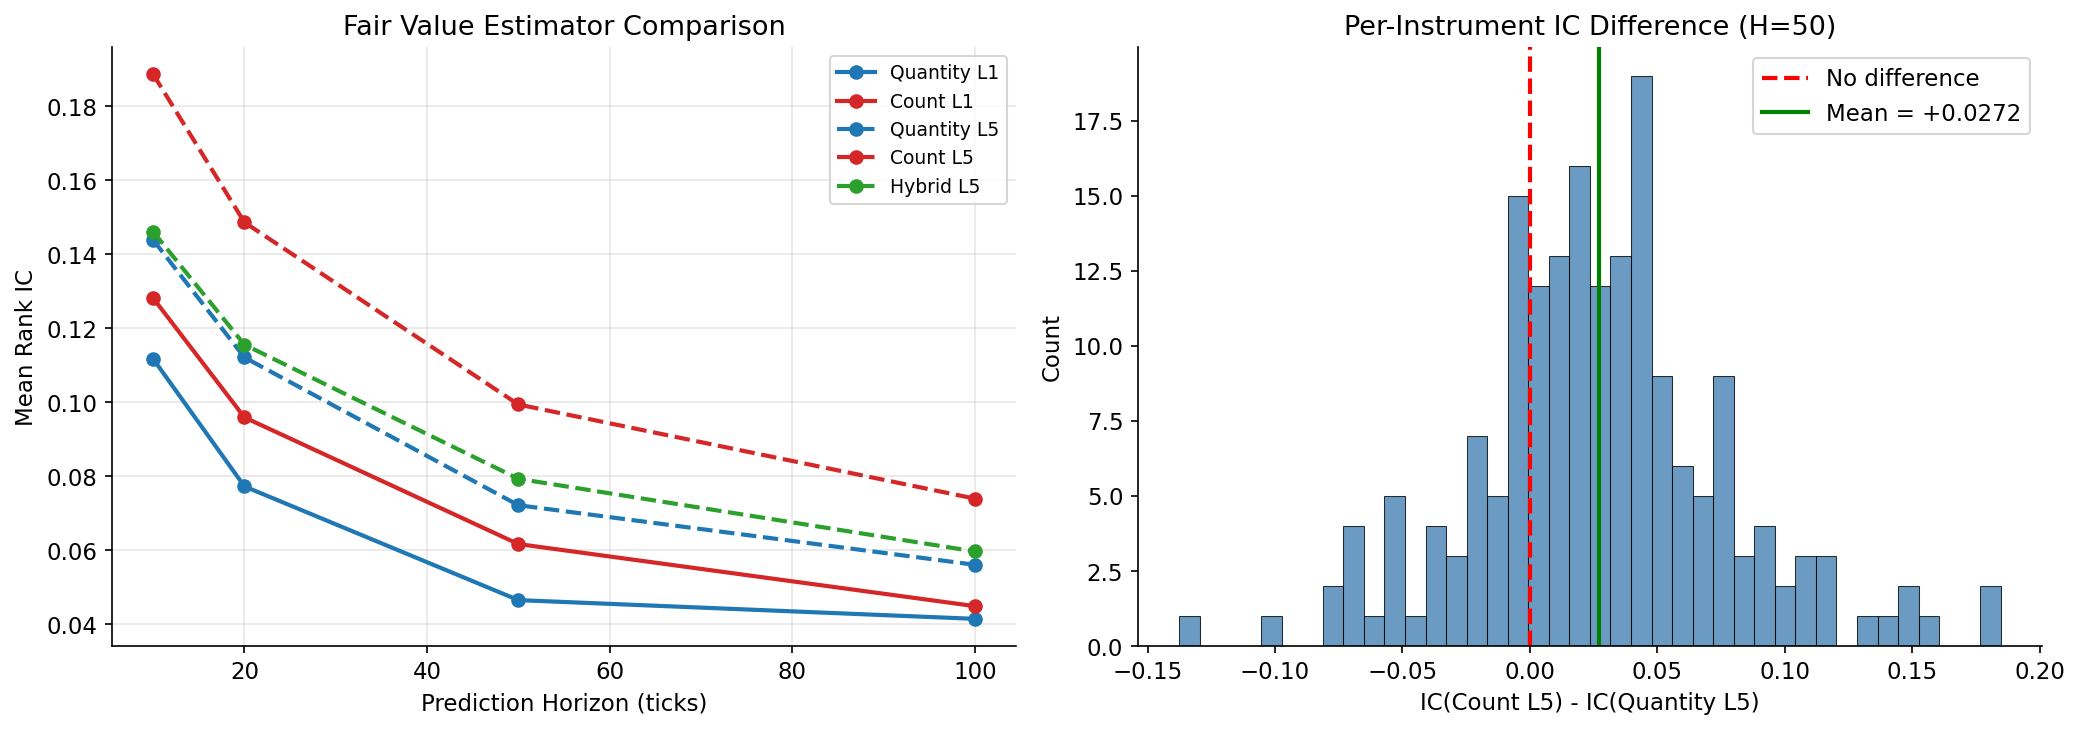

Saved to /content/drive/MyDrive/lob_fairvalue/outputs/fv_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for fn, color, ls in [('qty_L1','#1f77b4','-'), ('cnt_L1','#d62728','-'),
                       ('qty_L5','#1f77b4','--'), ('cnt_L5','#d62728','--'),
                       ('hyb_L5','#2ca02c','--')]:
    ys = []
    for h in HORIZONS:
        ics = [x for x in results[fn][h]['ic'] if np.isfinite(x)]
        ys.append(np.mean(ics) if ics else np.nan)
    label = fn.replace('_', ' ').replace('qty', 'Quantity').replace('cnt', 'Count').replace('hyb', 'Hybrid')
    ax.plot(HORIZONS, ys, marker='o', color=color, linestyle=ls, label=label, linewidth=2)

ax.set_xlabel('Prediction Horizon (ticks)')
ax.set_ylabel('Mean Rank IC')
ax.set_title('Fair Value Estimator Comparison')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
h = 50
ics_q = np.array([x for x in results['qty_L5'][h]['ic'] if np.isfinite(x)])
ics_c = np.array([x for x in results['cnt_L5'][h]['ic'] if np.isfinite(x)])
n_plot = min(len(ics_q), len(ics_c))
diff = ics_c[:n_plot] - ics_q[:n_plot]
ax.hist(diff, bins=40, color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='red', linewidth=2, linestyle='--', label='No difference')
ax.axvline(x=np.mean(diff), color='green', linewidth=2, label=f'Mean = {np.mean(diff):+.4f}')
ax.set_xlabel('IC(Count L5) - IC(Quantity L5)')
ax.set_ylabel('Count')
ax.set_title(f'Per-Instrument IC Difference (H={h})')
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'fv_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Saved to {OUT_DIR / "fv_comparison.png"}')

---

*End of research notebook.*